In [1]:
# =================================================================
# 01_baseline_training_and_evaluation — Rainfall-Only Features
# Research question: Can rainfall alone predict urban pluvial floods?
#
# Models: Random Forest | XGBoost | Logistic Regression | SVC
# Class imbalance handling: class_weight='balanced' / sample_weight
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.svm              import SVC
from sklearn.preprocessing    import StandardScaler
from sklearn.model_selection  import GroupShuffleSplit
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)

# ── 1. CONFIGURATION ──────────────────────────────────────────────
LIGHTWEIGHT_PATH       = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_LIGHTWEIGHT.pkl"
URBAN_THRESHOLD        = 20.0
THRESH_1H              = 7.0
THRESH_24H             = 1.0
PFDI_PLUVIAL_THRESHOLD = 1.0

FEATURE_COLS = [
    '30_max_rainfall_intens',  '60_max_rainfall_intens',
    '120_max_rainfall_intens', '240_max_rainfall_intens',
    '360_max_rainfall_intens', '720_max_rainfall_intens',
    '1440_max_rainfall_intens',
]

# ── 2. LOAD & FILTER ──────────────────────────────────────────────
print("Loading lightweight dataset...")
df = pd.read_pickle(LIGHTWEIGHT_PATH)

filtered_df = df[
    (df['urban_percentage']         >= URBAN_THRESHOLD) &
    (df['60_max_rainfall_intens']   >  THRESH_1H) &
    (df['1440_max_rainfall_intens'] >  THRESH_24H) &
    (df['PFDI_p99']                 <  PFDI_PLUVIAL_THRESHOLD)
].copy()

filtered_df['original_basin_id'] = (
    filtered_df['event_id'].apply(lambda x: str(x).split('_noflood_')[0])
)

n_flood    = (filtered_df['is_flood'] == 1).sum()
n_no_flood = (filtered_df['is_flood'] == 0).sum()
print(f"\nDataset after filtering: {len(filtered_df):,} samples")
print(f"  Flood (1):    {n_flood:,}  ({n_flood/len(filtered_df)*100:.1f}%)")
print(f"  No-flood (0): {n_no_flood:,}  ({n_no_flood/len(filtered_df)*100:.1f}%)")

# ── 3. FEATURES & SPLIT ───────────────────────────────────────────
feature_cols = [c for c in FEATURE_COLS if c in filtered_df.columns]
X      = filtered_df[feature_cols]
y      = filtered_df['is_flood']
groups = filtered_df['original_basin_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")

# ── 4. SCALED VERSIONS (for Logistic Regression and SVC) ─────────
# Fit scaler on train only — prevents data leakage into test set
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("StandardScaler fitted on training set.")

Loading lightweight dataset...

Dataset after filtering: 34,101 samples
  Flood (1):    32,685  (95.8%)
  No-flood (0): 1,416  (4.2%)

Train: 27,393 | Test: 6,708
StandardScaler fitted on training set.


In [2]:
# ── EVALUATION HELPERS ────────────────────────────────────────────

def evaluate_model(name, y_true, y_pred, y_proba):
    """Print classification report and return a metrics dict."""
    print(f"\n── {name} — Classification Report ─────────────────────────")
    print(classification_report(y_true, y_pred, target_names=['No Flood', 'Flood']))
    return {
        'Model':      name,
        'Precision':  precision_score(y_true, y_pred),
        'Recall':     recall_score(y_true, y_pred),
        'F1':         f1_score(y_true, y_pred),
        'AP (PR-AUC)': average_precision_score(y_true, y_proba),
    }


def plot_model(name, y_true, y_pred, y_proba, color, cmap, feat_imp_df=None):
    """
    Plot confusion matrix + PR curve, and optionally a feature importance bar chart.
    feat_imp_df: DataFrame with columns ['Feature', 'Importance'] — pass None to skip.
    """
    n_plots = 3 if feat_imp_df is not None else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    fig.suptitle(f'{name} — Rainfall-Only Features', fontsize=14, fontweight='bold')

    # Confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['No Flood', 'Flood']
    ).plot(ax=axes[0], cmap=cmap, colorbar=False)
    axes[0].set_title('Confusion Matrix')
    axes[0].grid(False)

    # Precision-Recall curve
    p, r, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)
    axes[1].plot(r, p, lw=2, color=color, label=f'AP = {ap:.3f}')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend()
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1])

    # Feature importance / coefficients (tree models and logistic regression)
    if feat_imp_df is not None:
        sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
                    ax=axes[2], palette='viridis')
        axes[2].set_title('Feature Importance')
        axes[2].set_xlabel('Relative Importance')
        axes[2].set_ylabel('')

    plt.tight_layout()
    plt.show()

print("Helper functions loaded.")

Helper functions loaded.


  1:1 → Flood F1=0.670 | No-Flood F1=0.081
  2:1 → Flood F1=0.970 | No-Flood F1=0.167
  3:1 → Flood F1=0.985 | No-Flood F1=0.040
  5:1 → Flood F1=0.987 | No-Flood F1=0.000
  10:1 → Flood F1=0.987 | No-Flood F1=0.000

── Ratio Exploration Results ────────────────────────────────
       Train Flood  Train No-Flood  Flood F1  No-Flood F1  No-Flood Recall  No-Flood Precision
Ratio                                                                                         
1:1           1248            1248     0.670        0.081            0.851               0.042
2:1           2496            1248     0.970        0.167            0.232               0.131
3:1           3744            1248     0.985        0.040            0.024               0.121
5:1           6240            1248     0.987        0.000            0.000               0.000
10:1         12480            1248     0.987        0.000            0.000               0.000


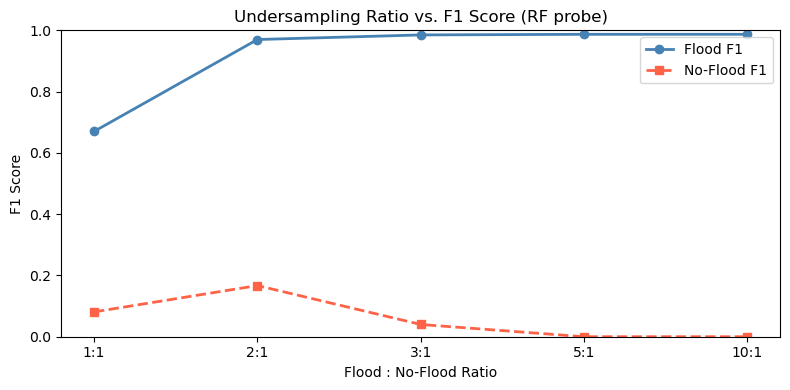


Balanced training set (ratio 3:1):
  Flood:    3,744
  No-Flood: 1,248
  Total:    4,992


In [3]:
# ── UNDERSAMPLING RATIO EXPLORATION ──────────────────────────────
# Goal: find the flood:no-flood ratio that gives the best trade-off
# between Flood F1 and No-Flood F1.
# We probe with RF only (fastest model) across 5 candidate ratios.

from sklearn.utils import resample

RATIOS_TO_TEST = [1, 2, 3, 5, 10]  # flood:no-flood multiplier

n_no_flood_train = (y_train == 0).sum()
n_flood_train    = (y_train == 1).sum()
probe_results    = []

for ratio in RATIOS_TO_TEST:
    n_flood_keep = min(n_no_flood_train * ratio, n_flood_train)

    # Separate classes in training set
    X_fl = X_train[y_train == 1];  y_fl = y_train[y_train == 1]
    X_nf = X_train[y_train == 0];  y_nf = y_train[y_train == 0]

    # Randomly undersample the flood class (no replacement)
    X_fl_down, y_fl_down = resample(
        X_fl, y_fl, replace=False, n_samples=n_flood_keep, random_state=42
    )

    X_tr_bal = pd.concat([X_fl_down, X_nf])
    y_tr_bal = pd.concat([y_fl_down, y_nf])

    # RF probe — no class_weight needed, data is already balanced by design
    probe = RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
    )
    probe.fit(X_tr_bal, y_tr_bal)
    y_pred_probe = probe.predict(X_test)

    probe_results.append({
        'Ratio':              f'{ratio}:1',
        'Train Flood':        n_flood_keep,
        'Train No-Flood':     n_no_flood_train,
        'Flood F1':           round(f1_score(y_test, y_pred_probe, pos_label=1), 3),
        'No-Flood F1':        round(f1_score(y_test, y_pred_probe, pos_label=0), 3),
        'No-Flood Recall':    round(recall_score(y_test, y_pred_probe, pos_label=0), 3),
        'No-Flood Precision': round(precision_score(y_test, y_pred_probe, pos_label=0), 3),
    })
    print(f"  {ratio}:1 → Flood F1={probe_results[-1]['Flood F1']:.3f} | "
          f"No-Flood F1={probe_results[-1]['No-Flood F1']:.3f}")

ratio_df = pd.DataFrame(probe_results).set_index('Ratio')
print("\n── Ratio Exploration Results ────────────────────────────────")
print(ratio_df.to_string())

# Plot Flood F1 vs No-Flood F1 across ratios
fig, ax = plt.subplots(figsize=(8, 4))
ratios_labels = [r['Ratio'] for r in probe_results]
ax.plot(ratios_labels, [r['Flood F1']    for r in probe_results],
        'o-',  color='steelblue', lw=2, label='Flood F1')
ax.plot(ratios_labels, [r['No-Flood F1'] for r in probe_results],
        's--', color='tomato',    lw=2, label='No-Flood F1')
ax.set_xlabel('Flood : No-Flood Ratio')
ax.set_ylabel('F1 Score')
ax.set_title('Undersampling Ratio vs. F1 Score (RF probe)')
ax.legend()
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

# ── SET CHOSEN RATIO & BUILD BALANCED TRAINING SET ────────────────
# Adjust UNDERSAMPLE_RATIO based on the plot above before running models.
UNDERSAMPLE_RATIO = 3  # flood:no-flood

n_flood_keep = min(n_no_flood_train * UNDERSAMPLE_RATIO, n_flood_train)
X_fl_down, y_fl_down = resample(
    X_train[y_train == 1], y_train[y_train == 1],
    replace=False, n_samples=n_flood_keep, random_state=42
)
X_train_bal = pd.concat([X_fl_down, X_train[y_train == 0]])
y_train_bal = pd.concat([y_fl_down, y_train[y_train == 0]])

# Scaled version for LR and SVC (use scaler already fitted on full X_train)
X_train_bal_scaled = scaler.transform(X_train_bal)

print(f"\nBalanced training set (ratio {UNDERSAMPLE_RATIO}:1):")
print(f"  Flood:    {(y_train_bal == 1).sum():,}")
print(f"  No-Flood: {(y_train_bal == 0).sum():,}")
print(f"  Total:    {len(y_train_bal):,}")

In [4]:
filtered_df

,uuid,event_id,start_time,end_time,duration_days,area_km2,urban_built_up_area_m2,urban_percentage,upa_max,upa_p95,...,30_max_rainfall_intens,60_max_rainfall_intens,120_max_rainfall_intens,240_max_rainfall_intens,360_max_rainfall_intens,720_max_rainfall_intens,1440_max_rainfall_intens,imerg_type,is_flood,original_basin_id
14,8c9a3dc419614cab9cf13efa51a4b2e8,310,960508800.0,960595200.0,2.0,0.509424,109864.0,21.566335,0.494849,0.327752,...,35.110001,23.240000,17.817500,12.63375,9.093333,4.834583,2.432708,final,1,310
26,1616737983c24ad1a60791eb31411e32,322,960508800.0,960595200.0,2.0,0.647051,173276.0,26.779344,22.754612,0.013494,...,32.070000,24.655000,19.390000,13.25500,9.430000,5.047083,2.539375,final,1,322
28,56db0c30236140d3b8d1e2761d04c541,324,960595200.0,960595200.0,1.0,0.161886,48772.0,30.127452,0.045148,0.025799,...,30.679998,24.054999,19.557499,12.29750,8.216666,4.252083,2.135625,final,1,324
48,e30dadc9232f46c3b439ffa7394d2314,344,960595200.0,960595200.0,1.0,0.897993,226209.0,25.190499,2.532964,0.237836,...,32.070000,24.655000,19.390000,13.25500,9.430000,5.047083,2.539375,final,1,344
58,c5703fb36ca8436298532e5385eb3c48,354,960595200.0,960681600.0,2.0,6.762940,1886648.0,27.896862,2.436281,0.657524,...,23.689999,15.879999,9.915000,6.33250,5.354167,2.697500,1.364583,final,1,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850751,14994514-aa1c-40f6-8580-0974ff7eedfd,280350_noflood_20230531,2023-05-31 09:00:00,2023-06-04 09:00:00,4.0,13.944267,8606374.0,61.719804,8.085520,0.654006,...,13.000000,12.720000,9.560000,5.76125,3.943333,2.047083,1.132708,final_no_flood,0,280350
850752,9245c17a-49f1-4e49-ae96-231d5f73f835,280350_noflood_20230420,2023-04-20 09:30:00,2023-04-24 09:30:00,4.0,13.944267,8606374.0,61.719804,8.085520,0.654006,...,10.110000,8.695000,7.232500,5.41875,5.012500,2.696250,1.361042,final_no_flood,0,280350
850753,84f43619-6e89-4696-8074-e5d97040315c,280350_noflood_20230519,2023-05-19 22:30:00,2023-05-23 22:30:00,4.0,13.944267,8606374.0,61.719804,8.085520,0.654006,...,8.450000,8.015000,7.602500,5.65625,3.832500,2.003333,1.034167,final_no_flood,0,280350
850754,79560f5f-702c-4fcd-87af-cbef18ff79e5,280350_noflood_20231123,2023-11-23 10:00:00,2023-11-27 10:00:00,4.0,13.944267,8606374.0,61.719804,8.085520,0.654006,...,7.980000,7.885000,6.332500,4.02875,3.130833,2.912500,1.875625,final_no_flood,0,280350


Training Random Forest...

── Random Forest — Classification Report ─────────────────────────
              precision    recall  f1-score   support

    No Flood       0.12      0.02      0.04       168
       Flood       0.98      1.00      0.99      6540

    accuracy                           0.97      6708
   macro avg       0.55      0.51      0.51      6708
weighted avg       0.95      0.97      0.96      6708



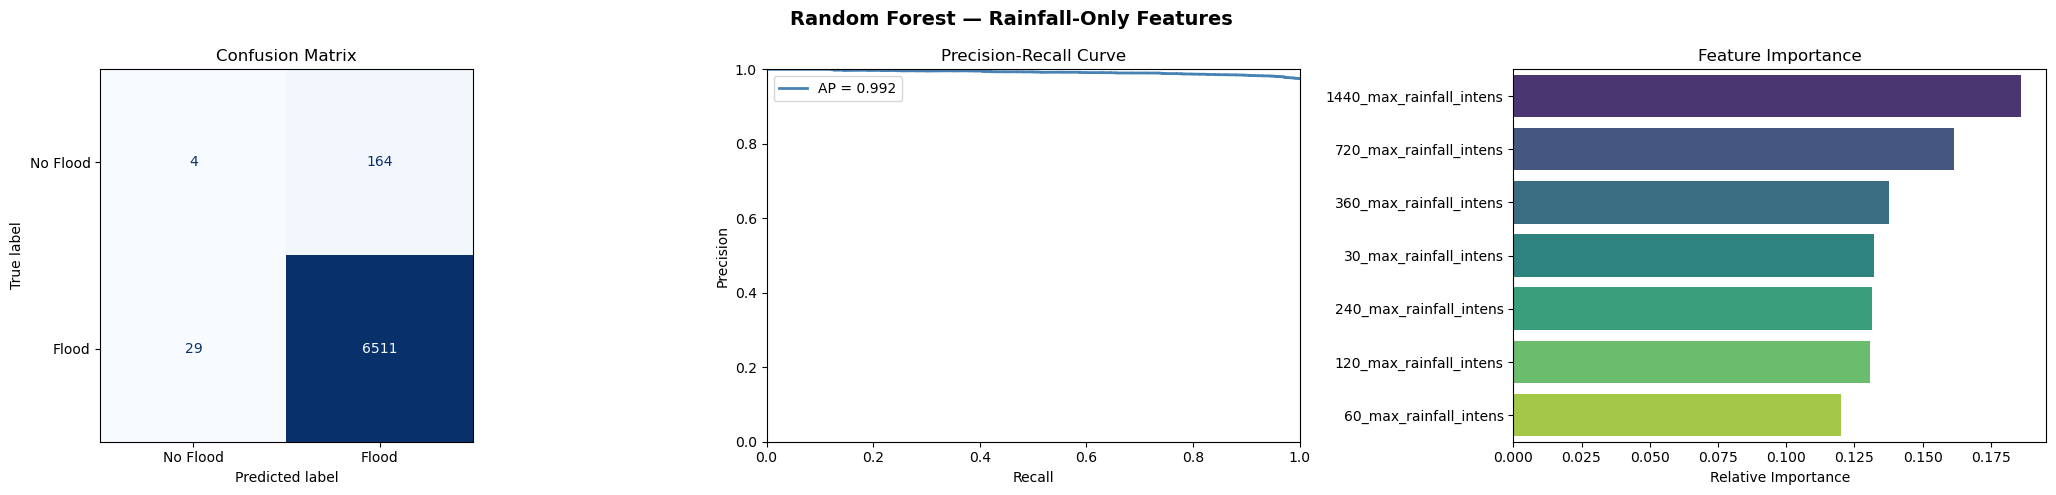

In [5]:
# ── MODEL 1: RANDOM FOREST ────────────────────────────────────────
# Trained on the undersampled balanced set — no class_weight needed.
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_bal, y_train_bal)

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

metrics_rf = evaluate_model('Random Forest', y_test, y_pred_rf, y_proba_rf)

feat_imp_rf = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': rf_model.feature_importances_,
}).sort_values('Importance', ascending=False)

plot_model('Random Forest', y_test, y_pred_rf, y_proba_rf,
           color='steelblue', cmap='Blues', feat_imp_df=feat_imp_rf)

Training XGBoost...

── XGBoost — Classification Report ─────────────────────────
              precision    recall  f1-score   support

    No Flood       0.09      0.05      0.07       168
       Flood       0.98      0.99      0.98      6540

    accuracy                           0.96      6708
   macro avg       0.53      0.52      0.52      6708
weighted avg       0.95      0.96      0.96      6708



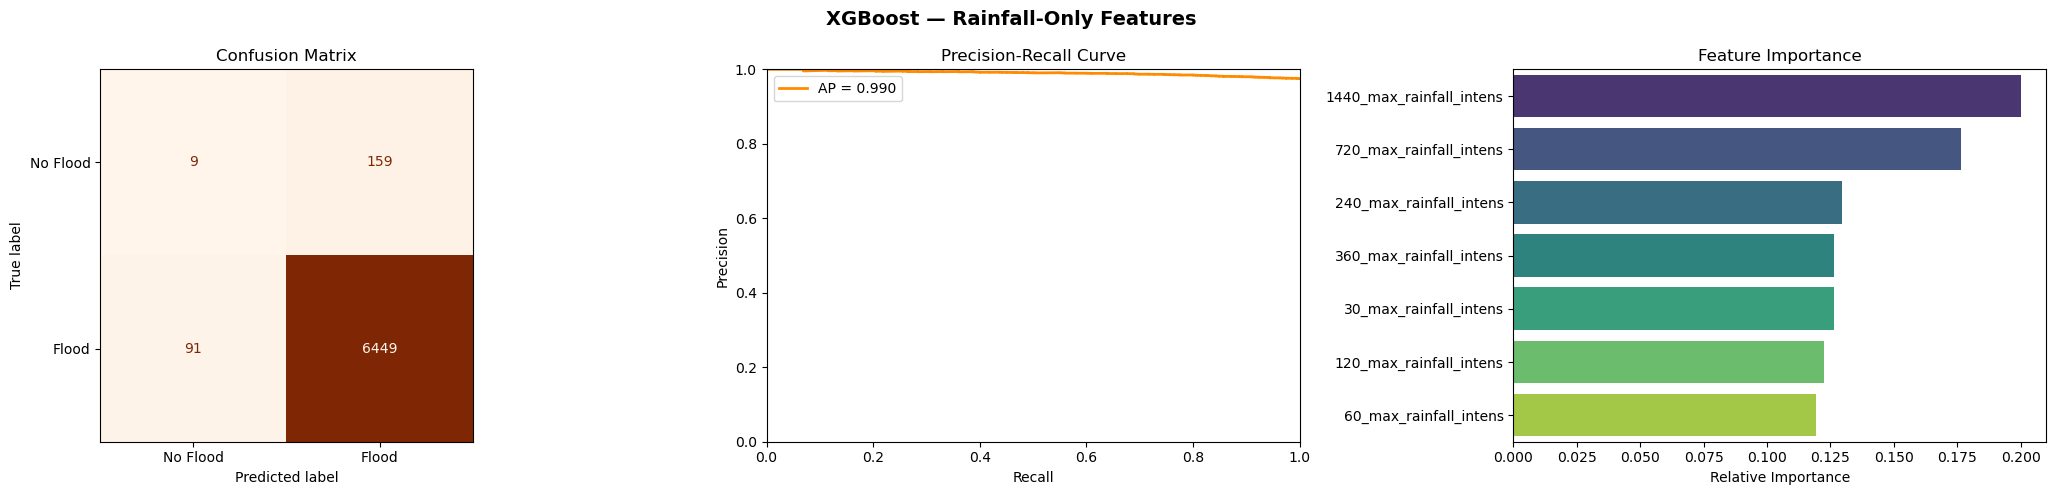

In [6]:
# ── MODEL 2: XGBOOST ──────────────────────────────────────────────
# Trained on the undersampled balanced set — no sample_weight needed.
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
)
xgb_model.fit(X_train_bal, y_train_bal)

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

metrics_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb)

feat_imp_xgb = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': xgb_model.feature_importances_,
}).sort_values('Importance', ascending=False)

plot_model('XGBoost', y_test, y_pred_xgb, y_proba_xgb,
           color='darkorange', cmap='Oranges', feat_imp_df=feat_imp_xgb)

Training Logistic Regression...

── Logistic Regression — Classification Report ─────────────────────────
              precision    recall  f1-score   support

    No Flood       0.00      0.00      0.00       168
       Flood       0.97      1.00      0.99      6540

    accuracy                           0.97      6708
   macro avg       0.49      0.50      0.49      6708
weighted avg       0.95      0.97      0.96      6708



C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


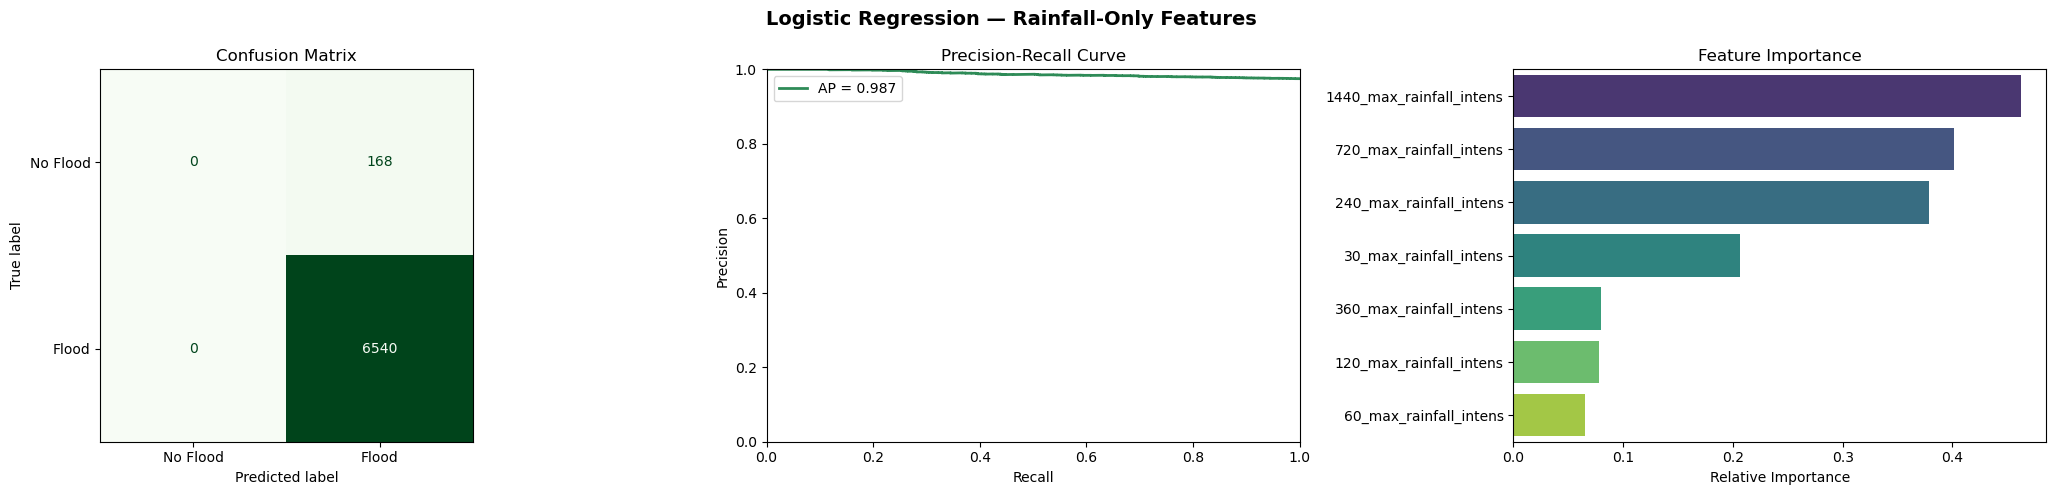

In [7]:
# ── MODEL 3: LOGISTIC REGRESSION ─────────────────────────────────
# Uses scaled balanced training set.
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_bal_scaled, y_train_bal)

y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

metrics_lr = evaluate_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr)

coef_df = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': np.abs(lr_model.coef_[0]),
}).sort_values('Importance', ascending=False)

plot_model('Logistic Regression', y_test, y_pred_lr, y_proba_lr,
           color='seagreen', cmap='Greens', feat_imp_df=coef_df)

Training SVC (this may take a moment on CPU)...

── SVC (RBF) — Classification Report ─────────────────────────
              precision    recall  f1-score   support

    No Flood       0.00      0.00      0.00       168
       Flood       0.97      1.00      0.99      6540

    accuracy                           0.97      6708
   macro avg       0.49      0.50      0.49      6708
weighted avg       0.95      0.97      0.96      6708



C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


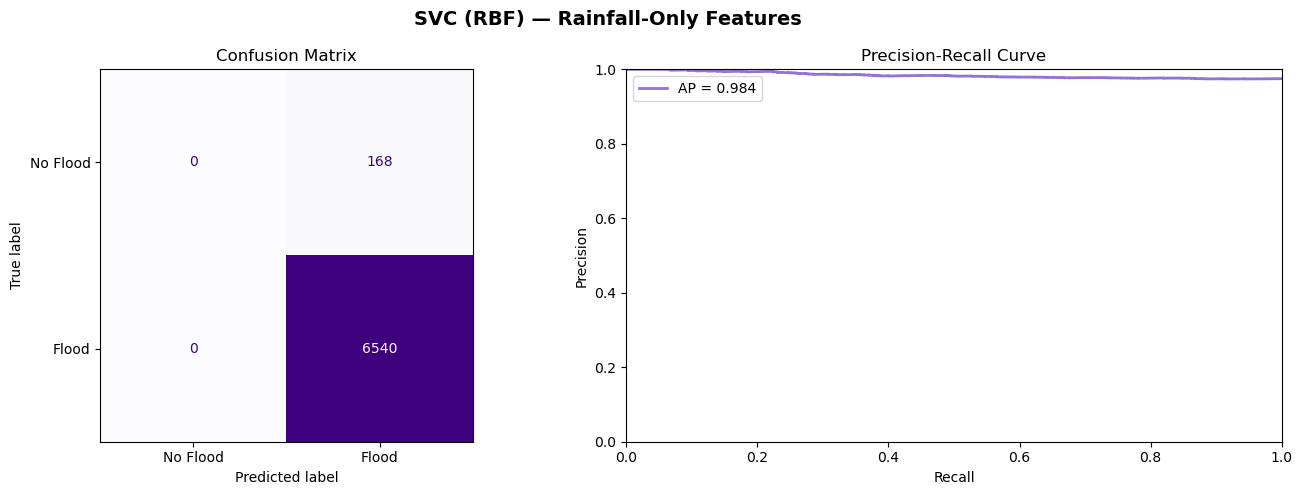

In [8]:
# ── MODEL 4: SVC (RBF KERNEL) ─────────────────────────────────────
# Uses scaled balanced training set.
# No feature importance available for RBF kernel.
print("Training SVC (this may take a moment on CPU)...")
svc_model = SVC(kernel='rbf', probability=True, random_state=42)
svc_model.fit(X_train_bal_scaled, y_train_bal)

y_pred_svc  = svc_model.predict(X_test_scaled)
y_proba_svc = svc_model.predict_proba(X_test_scaled)[:, 1]

metrics_svc = evaluate_model('SVC (RBF)', y_test, y_pred_svc, y_proba_svc)

plot_model('SVC (RBF)', y_test, y_pred_svc, y_proba_svc,
           color='mediumpurple', cmap='Purples')

── Test Set Comparison (Flood class) ───────────────────────
                     Precision  Recall     F1  AP (PR-AUC)
Model                                                     
Random Forest            0.975   0.996  0.985        0.992
XGBoost                  0.976   0.986  0.981        0.990
Logistic Regression      0.975   1.000  0.987        0.987
SVC (RBF)                0.975   1.000  0.987        0.984


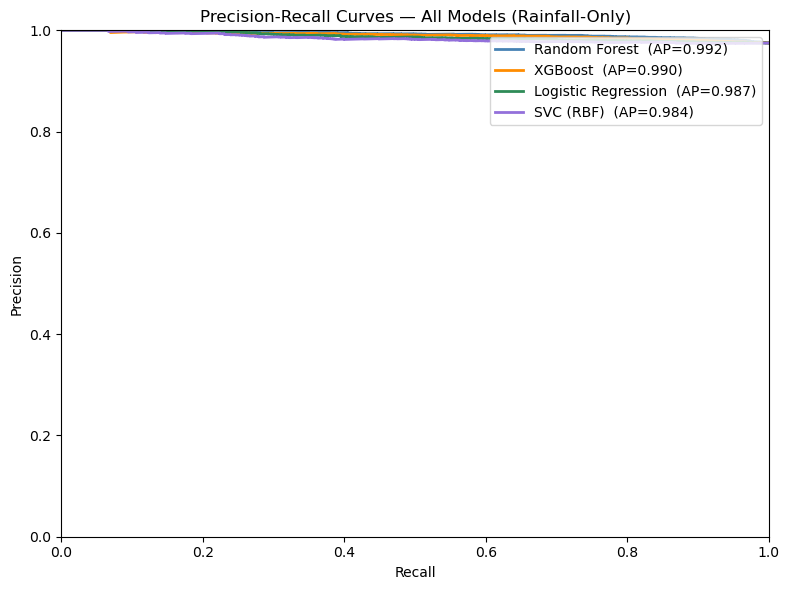

In [9]:
# ── MODEL COMPARISON ──────────────────────────────────────────────
comparison = pd.DataFrame([metrics_rf, metrics_xgb, metrics_lr, metrics_svc])
comparison = comparison.set_index('Model').round(3)

print("── Test Set Comparison (Flood class) ───────────────────────")
print(comparison.to_string())

# Combined Precision-Recall curve for all models
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba, color in [
    ('Random Forest',      y_proba_rf,  'steelblue'),
    ('XGBoost',            y_proba_xgb, 'darkorange'),
    ('Logistic Regression',y_proba_lr,  'seagreen'),
    ('SVC (RBF)',          y_proba_svc, 'mediumpurple'),
]:
    p, r, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ax.plot(r, p, lw=2, color=color, label=f'{name}  (AP={ap:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models (Rainfall-Only)')
ax.legend(loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.show()

In [10]:
# ── SANITY CHECK: Train Set Inference (Overfitting Detection) ─────
# If train performance is vastly higher than test, the model is overfitting.

models_sanity = [
    ('Random Forest',       rf_model,  X_train_bal,        y_train_bal),
    ('XGBoost',             xgb_model, X_train_bal,        y_train_bal),
    ('Logistic Regression', lr_model,  X_train_bal_scaled, y_train_bal),
    ('SVC (RBF)',           svc_model, X_train_bal_scaled, y_train_bal),
]

for name, model, X_tr, y_tr in models_sanity:
    print(f"── {name} — Train Set Performance ─────────────────────────")
    y_pred_train = model.predict(X_tr)
    print(classification_report(y_tr, y_pred_train, target_names=['No Flood', 'Flood']))

── Random Forest — Train Set Performance ─────────────────────────
              precision    recall  f1-score   support

    No Flood       0.99      0.15      0.25      1248
       Flood       0.78      1.00      0.88      3744

    accuracy                           0.79      4992
   macro avg       0.88      0.57      0.56      4992
weighted avg       0.83      0.79      0.72      4992

── XGBoost — Train Set Performance ─────────────────────────
              precision    recall  f1-score   support

    No Flood       0.98      0.12      0.22      1248
       Flood       0.77      1.00      0.87      3744

    accuracy                           0.78      4992
   macro avg       0.88      0.56      0.54      4992
weighted avg       0.83      0.78      0.71      4992

── Logistic Regression — Train Set Performance ─────────────────────────
              precision    recall  f1-score   support

    No Flood       0.00      0.00      0.00      1248
       Flood       0.75      1.00   

C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

    No Flood       0.00      0.00      0.00      1248
       Flood       0.75      1.00      0.86      3744

    accuracy                           0.75      4992
   macro avg       0.38      0.50      0.43      4992
weighted avg       0.56      0.75      0.64      4992



C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\raznu\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
